# Cell type annotation (3-layer pipeline)

This notebook continues from `02_Xenium_5k_downstream_qc_filter_clustering_python.ipynb`: it annotates the `leiden` clusters using three complementary layers of evidence.

1. **Canonical/known marker annotation** — score each cluster against curated literature marker gene sets.
2. **DEG-driven manual annotation** — pull top DEGs per cluster, cross-check against literature/Protein Atlas, and record a manual label.
3. **Functional enrichment (GO/KEGG/Reactome)** — run over-representation analysis on cluster DEGs to support/refine the label.

Outputs are written to `results/xenium_5k/annotation/`.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import spatialdata as sd
import spatialdata_plot
import gseapy as gp

%load_ext autoreload
%autoreload 2

warnings.filterwarnings("ignore")

annot_dir = "../../results/xenium_5k/annotation"
os.makedirs(annot_dir, exist_ok=True)

/home/duydao/micromamba/envs/spatial_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the processed sample saved at the end of notebook 02
sdata = sd.read_zarr("../../data/xenium_prime_5k_processed.zarr")
adata = sdata["table"]
adata.obs["leiden"] = adata.obs["leiden"].astype("category")
clusters = adata.obs["leiden"].cat.categories.tolist()
print(f"{len(clusters)} clusters, {adata.n_obs} cells")

no parent found for <ome_zarr.reader.Label object at 0x782d18335d60>: None
no parent found for <ome_zarr.reader.Label object at 0x782d18361e80>: None


20 clusters, 266179 cells


## Layer 1 — Canonical/known marker annotation

Curated literature marker sets for human lung tissue (epithelial, immune, stromal). Edit/extend this dict as needed for the tissue at hand.

In [5]:
canonical_markers = {
    "Epithelial: AT1": ["AGER", "PDPN", "CAV1"],
    "Epithelial: AT2": ["SFTPC", "SFTPB", "SFTPA1", "NAPSA"],
    "Epithelial: Airway (Ciliated)": ["FOXJ1", "TPPP3", "PIFO"],
    "Epithelial: Airway (Club/Secretory)": ["SCGB1A1", "SCGB3A1", "MUC5B"],
    "Epithelial: Tumor/Malignant": ["EPCAM", "KRT8", "KRT18", "KRT19"],
    "Epithelial: LUAD (Adenocarcinoma)": ["NAPSA", "NKX2-1", "SFTPC", "SFTPB", "MUC5AC", "MUC5B", "KRT7"],
    "Immune: T cell": ["CD3D", "CD3E", "CD2", "TRAC"],
    "Immune: NK cell": ["NKG7", "GNLY", "KLRD1"],
    "Immune: B cell": ["MS4A1", "CD79A", "CD79B"],
    "Immune: Plasma cell": ["MZB1", "JCHAIN", "IGHG1"],
    "Immune: Myeloid": ["CD68", "CD74", "LYZ", "ITGAM", "AIF1"],
    "Immune: Mast cell": ["TPSAB1", "TPSB2", "CPA3"],
    "Stromal: Fibroblast": ["COL1A1", "COL1A2", "DCN", "PDGFRA"],
    "Stromal: Endothelial": ["PECAM1", "VWF", "CLDN5"],
    "Stromal: Smooth muscle/Pericyte": ["ACTA2", "MYH11", "PDGFRB"],
}

# Keep only genes present in the panel, and drop cell types left with no genes
canonical_markers = {
    cell_type: [g for g in genes if g in adata.var_names]
    for cell_type, genes in canonical_markers.items()
}
missing = {k: v for k, v in canonical_markers.items() if len(v) == 0}
if missing:
    print("Cell types with no marker genes found in panel (dropped):", list(missing.keys()))
canonical_markers = {k: v for k, v in canonical_markers.items() if len(v) > 0}

Cell types with no marker genes found in panel (dropped): ['Epithelial: AT2', 'Immune: Mast cell']


In [10]:
# Score each cell for each canonical cell type signature
for cell_type, genes in canonical_markers.items():
    sc.tl.score_genes(adata, gene_list=genes, score_name=f"score_{cell_type}", layer="lognorm")

score_cols = [f"score_{ct}" for ct in canonical_markers]
cluster_scores = adata.obs.groupby("leiden", observed=True)[score_cols].mean()
cluster_scores.columns = list(canonical_markers.keys())
cluster_scores

,Epithelial: AT1,Epithelial: Airway (Ciliated),Epithelial: Airway (Club/Secretory),Epithelial: Tumor/Malignant,Epithelial: LUAD (Adenocarcinoma),Immune: T cell,Immune: NK cell,Immune: B cell,Immune: Plasma cell,Immune: Myeloid,Stromal: Fibroblast,Stromal: Endothelial,Stromal: Smooth muscle/Pericyte
leiden,,,,,,,,,,,,,
0,-0.058396,-0.026071,-0.022908,-0.120258,-0.045489,0.443417,-0.002120,-0.002850,-0.015511,-0.013936,-0.019069,-0.121615,-0.060902
1,-0.019504,-0.021899,-0.017447,-0.081082,-0.038742,0.376795,0.101915,-0.017406,-0.023242,-0.016811,-0.034741,-0.080540,-0.067419
2,-0.061176,-0.035192,-0.039876,-0.128915,-0.048469,0.007108,-0.003248,0.463669,0.002344,0.008288,-0.013399,-0.122100,-0.067968
3,-0.075806,-0.025936,-0.023786,-0.119475,-0.045994,-0.028614,-0.002546,0.172094,1.011208,-0.010263,0.023065,0.005798,-0.040419
4,-0.094719,-0.008780,-0.028221,0.556935,0.099046,-0.149774,-0.005590,-0.041581,-0.058279,-0.071132,-0.074161,-0.227930,-0.119373
5,-0.063998,-0.020721,-0.020539,-0.110042,-0.057472,-0.056677,-0.005616,-0.024264,-0.027349,-0.025523,0.249662,-0.133548,0.193960
6,-0.075142,-0.024621,-0.023890,-0.120994,-0.059598,-0.062378,-0.005397,-0.028092,-0.039084,0.309424,-0.029730,-0.079777,-0.069153
7,0.013782,-0.010713,-0.012400,-0.059679,-0.023658,-0.035956,-0.002123,-0.012739,-0.016023,0.024847,0.003067,-0.005898,-0.016678
8,-0.086727,0.011992,-0.026173,0.551009,0.036891,-0.130063,-0.010144,-0.036121,-0.051571,-0.065128,-0.064777,-0.206642,-0.109816


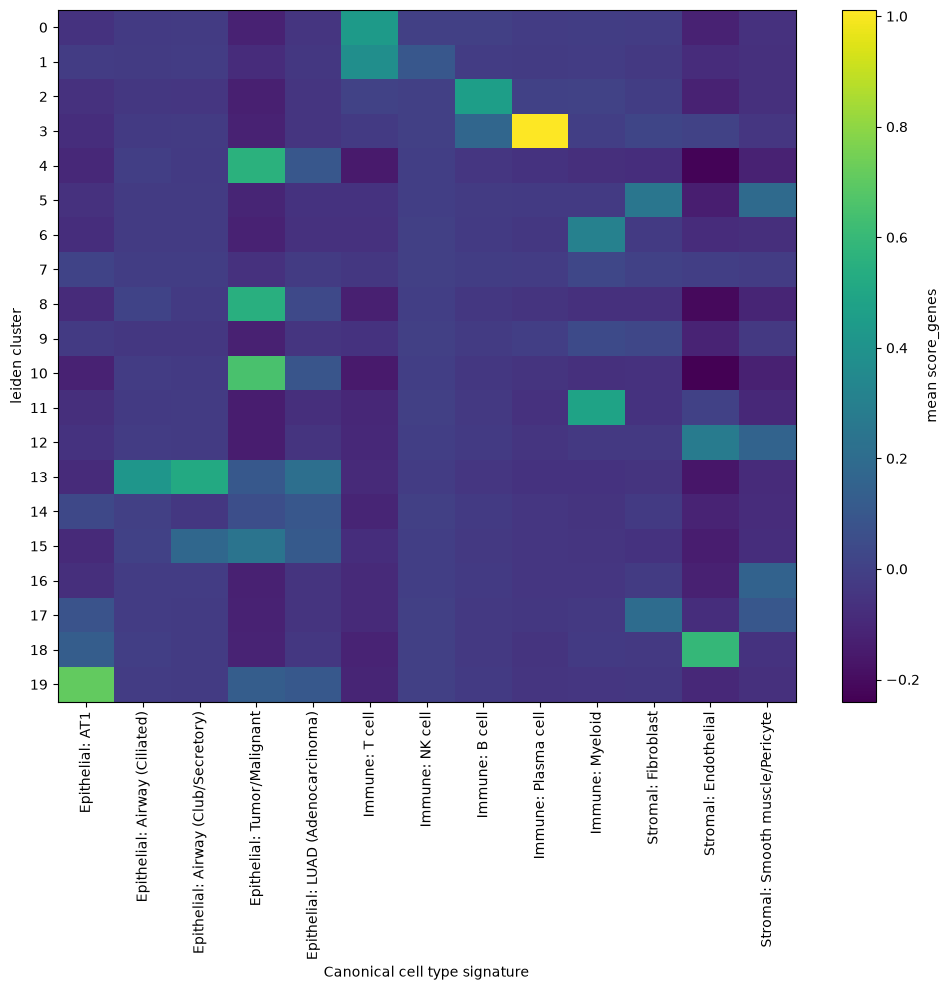

In [7]:
# Heatmap of mean marker score per cluster
fig, ax = plt.subplots(figsize=(10, 0.4 * len(cluster_scores) + 2))
im = ax.imshow(cluster_scores.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(cluster_scores.columns)))
ax.set_xticklabels(cluster_scores.columns, rotation=90)
ax.set_yticks(range(len(cluster_scores)))
ax.set_yticklabels(cluster_scores.index)
ax.set_xlabel("Canonical cell type signature")
ax.set_ylabel("leiden cluster")
fig.colorbar(im, ax=ax, label="mean score_genes")
plt.tight_layout()

In [8]:
# First-pass label per cluster: cell type with the highest mean score
layer1_annotation = pd.DataFrame({
    "cluster": cluster_scores.index,
    "canonical_label": cluster_scores.idxmax(axis=1).values,
    "canonical_score": cluster_scores.max(axis=1).values,
}).reset_index(drop=True)
layer1_annotation

,cluster,canonical_label,canonical_score
0,0,Immune: T cell,0.443417
1,1,Immune: T cell,0.376795
2,2,Immune: B cell,0.463669
3,3,Immune: Plasma cell,1.011208
4,4,Epithelial: Tumor/Malignant,0.556935
5,5,Stromal: Fibroblast,0.249662
6,6,Immune: Myeloid,0.309424
7,7,Immune: Myeloid,0.024847
8,8,Epithelial: Tumor/Malignant,0.551009
9,9,Immune: Myeloid,0.042712


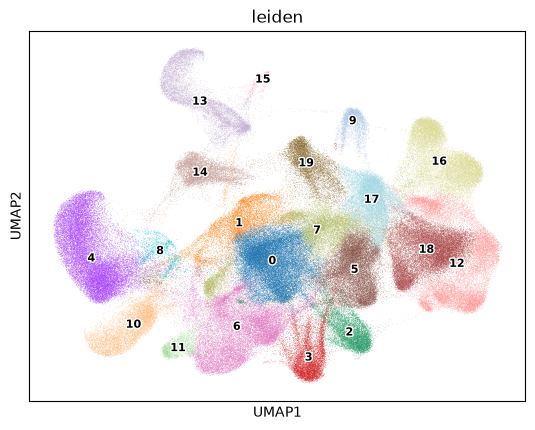

In [9]:
# UMAP with cluster id printed directly on the plot instead of a side legend
sc.pl.umap(adata, color="leiden", legend_loc="on data", legend_fontsize=8, legend_fontoutline=2)

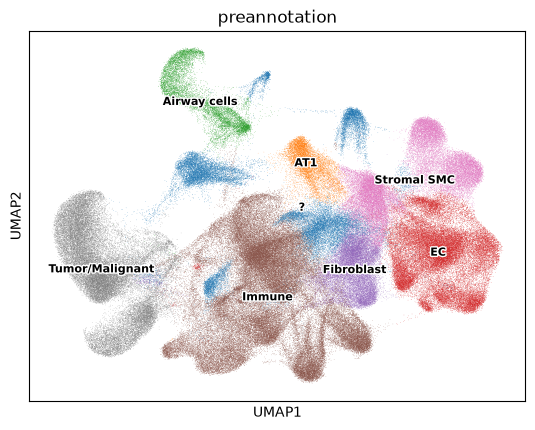

In [ ]:
preannotation_groups = {
    "Treg": ["0"],
    "T_cytotoxic": ["1"],
    "B_cell": ["2"],
    "Plasma": ["3"],
    "Tumor_epithelial": ["4", "8", "10"],
    "Fibroblast": ["5", "17"],
    "Macrophage": ["6", "11"],
    "Neutrophil": ["7"],
    "Mast": ["9"],
    "EC": ["12", "18"],
    "Ciliated": ["13"],
    "AT2": ["14"],
    "PNECs": ["15"],
    "SMC/MC": ["16"],
    "AT1": ["19"],
}

# Manual eyeball pre-annotation from the UMAP above, used as a sanity check ahead of layers 1-3
cluster_to_preannotation = {c: label for label, cs in preannotation_groups.items() for c in cs}
adata.obs["preannotation"] = adata.obs["leiden"].map(cluster_to_preannotation).astype("category")

sc.pl.umap(adata, color="preannotation", legend_loc="on data", legend_fontsize=8, legend_fontoutline=2)


## Layer 2 — DEG-driven manual/literature annotation

Compute DEGs per cluster, pull the top 5–10 genes, then cross-check them against literature / [Human Protein Atlas](https://www.proteinatlas.org) to assign a label (e.g. cluster 1 top gene `CD74` → `Immune: Myeloid`).

Manual calls are stored in an editable CSV (`layer2_manual_annotation.csv`) so re-running this notebook doesn't wipe out annotation work — edit the CSV directly and re-run the load cell to pick up changes.

In [13]:
sc.tl.rank_genes_groups(adata, groupby="leiden", layer="lognorm", pts=True)

In [14]:
n_top_degs = 10
deg_summary = pd.concat(
    [sc.get.rank_genes_groups_df(adata, group=c).head(n_top_degs).assign(cluster=c) for c in clusters],
    ignore_index=True,
)
deg_summary = deg_summary[["cluster", "names", "scores", "logfoldchanges", "pvals_adj", "pct_nz_group", "pct_nz_reference"]]
deg_summary.to_csv(f"{annot_dir}/deg_summary.csv", index=False)
deg_summary.head(10)

,cluster,names,scores,logfoldchanges,pvals_adj,pct_nz_group,pct_nz_reference
0,0,CXCR4,212.362320,3.017723,0.0,0.797112,0.239101
1,0,CD3E,191.490143,4.065363,0.0,0.666677,0.079164
2,0,EEF1G,120.928795,0.975541,0.0,0.928146,0.836647
3,0,CD2,99.916603,3.807193,0.0,0.318347,0.032474
4,0,CTLA4,96.082680,4.062224,0.0,0.300344,0.032304
5,0,CD44,93.627914,1.380983,0.0,0.573604,0.377878
6,0,ITGAL,92.580574,2.836432,0.0,0.326197,0.072481
7,0,IL2RG,91.974373,2.744182,0.0,0.328341,0.076678
8,0,CCR4,90.593658,4.695188,0.0,0.257338,0.015371
9,0,IKZF1,90.178772,2.727143,0.0,0.317558,0.070626


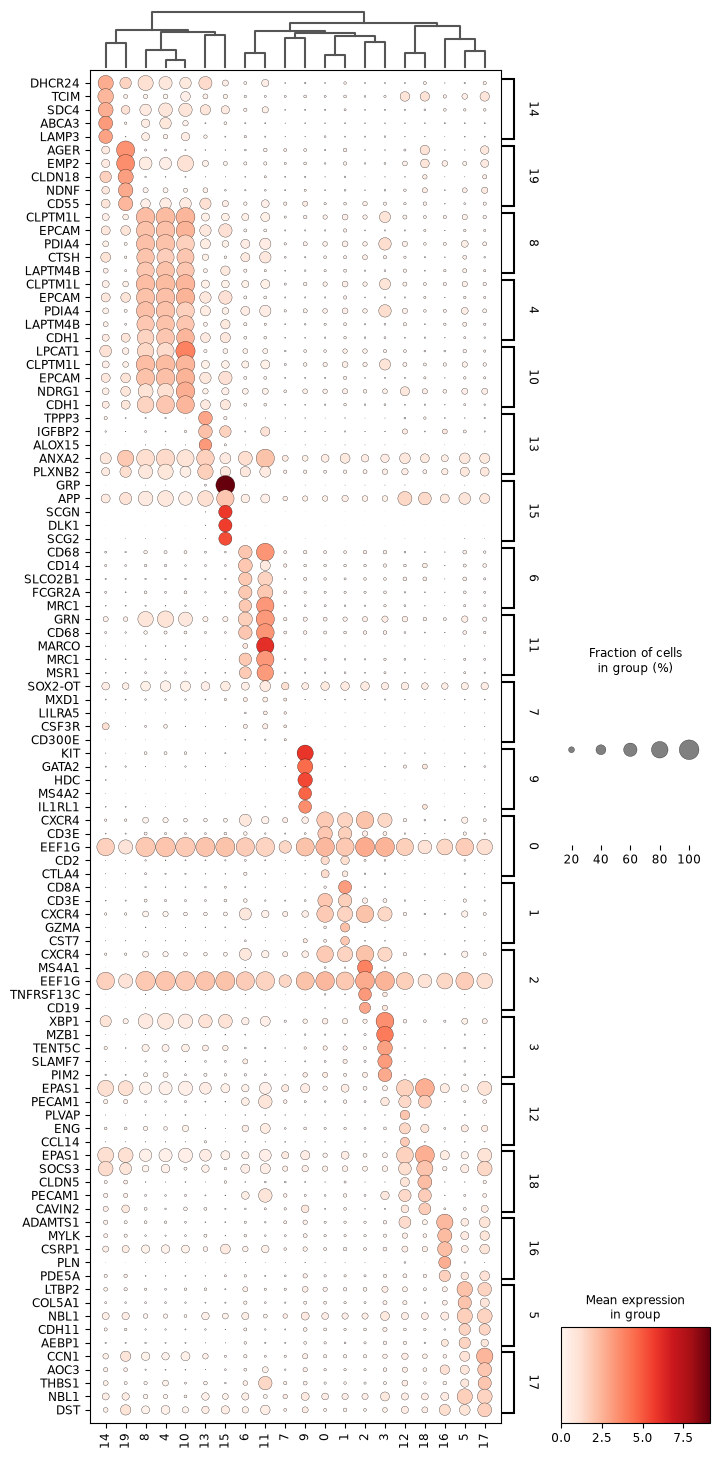

In [18]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5, swap_axes=True, figsize=(8, 18))

In [19]:
# Build (or reload) the manual annotation table: one row per cluster
layer2_path = f"{annot_dir}/layer2_manual_annotation.csv"
top_degs_per_cluster = (
    deg_summary.groupby("cluster", observed=True)["names"]
    .apply(lambda s: ", ".join(s))
    .reindex(clusters)
)

if os.path.exists(layer2_path):
    # Reload existing manual work, refreshing the auto-generated top_degs column
    layer2_manual_annotation = pd.read_csv(layer2_path, dtype=str).set_index("cluster")
    layer2_manual_annotation["top_degs"] = top_degs_per_cluster
    layer2_manual_annotation = layer2_manual_annotation.reset_index()
else:
    layer2_manual_annotation = pd.DataFrame({
        "cluster": clusters,
        "top_degs": top_degs_per_cluster.values,
        "literature_notes": "",
        "layer2_label": "",
    })

layer2_manual_annotation.to_csv(layer2_path, index=False)
print(f"Edit {layer2_path} to fill in literature_notes / layer2_label, then re-run this cell to reload.")
layer2_manual_annotation

Edit ../../results/xenium_5k/annotation/layer2_manual_annotation.csv to fill in literature_notes / layer2_label, then re-run this cell to reload.


,cluster,top_degs,literature_notes,layer2_label
0,0,"CXCR4, CD3E, EEF1G, CD2, CTLA4, CD44, ITGAL, I...",,
1,1,"CD8A, CD3E, CXCR4, GZMA, CST7, ITGAL, KLRK1, G...",,
2,2,"CXCR4, MS4A1, EEF1G, TNFRSF13C, CD19, CD79A, B...",,
3,3,"XBP1, MZB1, TENT5C, SLAMF7, PIM2, DERL3, POU2A...",,
4,4,"CLPTM1L, EPCAM, PDIA4, LAPTM4B, CDH1, NKX2-1, ...",,
5,5,"LTBP2, COL5A1, NBL1, CDH11, AEBP1, CCDC80, MMP...",,
6,6,"CD68, CD14, SLCO2B1, FCGR2A, MRC1, GRN, MSR1, ...",,
7,7,"SOX2-OT, MXD1, LILRA5, CSF3R, CD300E, FPR1, C5...",,
8,8,"CLPTM1L, EPCAM, PDIA4, CTSH, LAPTM4B, TUBB, P4...",,
9,9,"KIT, GATA2, HDC, MS4A2, IL1RL1, SLC18A2, CD44,...",,


#### Cross-check top DEGs against HPA marker genes

Fisher's exact test (via `celltypegenomics`) of each cluster's top DEGs against Human Protein Atlas cell-type marker gene sets, as an additional cross-check for the manual calls above.

In [20]:
from celltypegenomics import celltypefishertest

symbol_to_ensembl = adata.var["gene_ids"].to_dict()


def hpa_fisher_test(cluster, n=n_top_degs):
    genes = deg_summary.loc[deg_summary["cluster"] == cluster, "names"].head(n)
    ensembl_ids = [symbol_to_ensembl[g] for g in genes if g in symbol_to_ensembl]
    result = celltypefishertest(ensembl_ids, hpa_marker_genes=True)
    return result.sort_values("adjusted_p_value").assign(cluster=cluster)


hpa_annotation = pd.concat([hpa_fisher_test(c) for c in clusters], ignore_index=False)
hpa_annotation.to_csv(f"{annot_dir}/layer2_hpa_fishertest.csv")
hpa_annotation.groupby("cluster").head(3)

,p_value,odds_ratio,count_in_both,count_in_genelist_not_cell_type,count_in_cell_type_not_genelist,count_in_neither,adjusted_p_value,cluster
T-cells,6.640537e-07,5.037750e+03,2,8,1,20151,3.585890e-05,1
Dendritic cells,4.959825e-04,inf,1,9,0,20152,1.339153e-02,1
B-cells,6.640537e-07,5.037750e+03,2,8,1,20151,3.585890e-05,2
Macrophages,8.781527e-10,4.317857e+03,3,7,2,20150,4.742025e-08,6
Hofbauer cells,6.640537e-07,5.037750e+03,2,8,1,20151,1.792945e-05,6
Granulocytes,6.640537e-07,5.037750e+03,2,8,1,20151,3.585890e-05,9
Spermatogonia,1.487283e-03,1.119444e+03,1,9,2,20150,4.015665e-02,9
Macrophages,1.525078e-13,1.343400e+04,4,6,1,20151,8.235419e-12,11
Kupffer cells,1.487283e-03,1.119444e+03,1,9,2,20150,2.677110e-02,11
Hofbauer cells,1.487283e-03,1.119444e+03,1,9,2,20150,2.677110e-02,11


In [21]:
# Best-scoring HPA cell type per cluster (lowest adjusted p-value)
hpa_best_per_cluster = (
    hpa_annotation.reset_index(names="cell_type")
    .sort_values("adjusted_p_value")
    .groupby("cluster", sort=False)
    .first()
    .reindex(clusters)[["cell_type", "adjusted_p_value", "odds_ratio"]]
)
hpa_best_per_cluster

,cell_type,adjusted_p_value,odds_ratio
cluster,,,
0,NaN,NaN,NaN
1,T-cells,3.585890e-05,5037.750000
2,B-cells,3.585890e-05,5037.750000
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,NaN,NaN,NaN
6,Macrophages,4.742025e-08,4317.857143
7,NaN,NaN,NaN
8,NaN,NaN,NaN


## Result of Layer 2

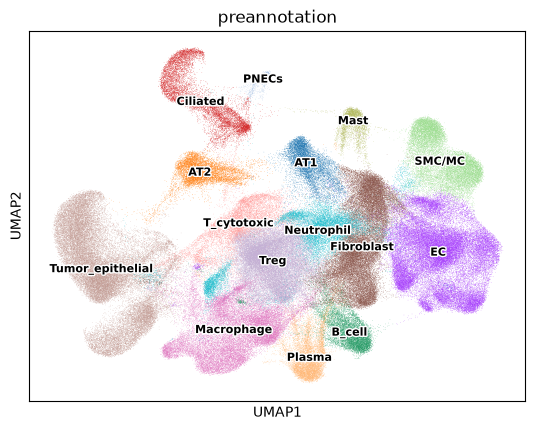

In [23]:
preannotation_groups = {
    "Treg": ["0"],
    "T_cytotoxic": ["1"],
    "B_cell": ["2"],
    "Plasma": ["3"],
    "Tumor_epithelial": ["4", "8", "10"],
    "Fibroblast": ["5", "17"],
    "Macrophage": ["6", "11"],
    "Neutrophil": ["7"],
    "Mast": ["9"],
    "EC": ["12", "18"],
    "Ciliated": ["13"],
    "AT2": ["14"],
    "PNECs": ["15"],
    "SMC/MC": ["16"],
    "AT1": ["19"],
}

# Manual eyeball pre-annotation from the UMAP above, used as a sanity check ahead of layers 1-3
cluster_to_preannotation = {c: label for label, cs in preannotation_groups.items() for c in cs}
adata.obs["preannotation"] = adata.obs["leiden"].map(cluster_to_preannotation).astype("category")

sc.pl.umap(adata, color="preannotation", legend_loc="on data", legend_fontsize=8, legend_fontoutline=2)


## Layer 3 — Functional enrichment (GO / KEGG / Reactome)

Over-representation analysis (Enrichr) on the top DEGs of each cluster, to support/refine the cell type call with pathway-level evidence.

In [24]:
gene_sets = ["GO_Biological_Process_2023", "KEGG_2021_Human", "Reactome_2022"]
n_genes_enrichment = 50


def top_deg_genes(cluster, n=n_genes_enrichment, padj_thresh=0.05):
    df = sc.get.rank_genes_groups_df(adata, group=cluster)
    df = df[(df["pvals_adj"] < padj_thresh) & (df["logfoldchanges"] > 0)]
    return df.sort_values("scores", ascending=False)["names"].head(n).tolist()


def run_enrichment(gene_list, cluster, gene_sets=gene_sets):
    if len(gene_list) == 0:
        return pd.DataFrame()
    try:
        enr = gp.enrich_multi(gene_list=gene_list, gene_sets=gene_sets, organism="human", outdir=None)
    except AttributeError:
        # older/newer gseapy versions expose enrichr per-library instead of enrich_multi
        enr = pd.concat(
            [gp.enrichr(gene_list=gene_list, gene_sets=[gs], organism="human", outdir=None).results.assign(Gene_set=gs)
             for gs in gene_sets],
            ignore_index=True,
        )
    enr = enr.results if hasattr(enr, "results") else enr
    enr["cluster"] = cluster
    return enr

In [25]:
%%time
enrichment_results = {}
for c in clusters:
    genes = top_deg_genes(c)
    res = run_enrichment(genes, c)
    if not res.empty:
        enrichment_results[c] = res

layer3_enrichment = pd.concat(enrichment_results.values(), ignore_index=True) if enrichment_results else pd.DataFrame()
layer3_enrichment.to_csv(f"{annot_dir}/layer3_functional_enrichment.csv", index=False)
layer3_enrichment.head(10)

CPU times: user 4.47 s, sys: 150 ms, total: 4.62 s
Wall time: 3min 48s


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,cluster
0,GO_Biological_Process_2023,T Cell Activation (GO:0042110),12/111,4.716093e-17,2.923978e-14,0,0,63.320574,2380.408186,CD2;ITK;ZAP70;CD4;LCK;CD28;CD3G;CD247;CD3E;FOX...,0
1,GO_Biological_Process_2023,T Cell Receptor Signaling Pathway (GO:0050852),9/95,1.782206e-12,5.524838e-10,0,0,50.702212,1371.655532,ITK;ZAP70;LCK;CD28;CTLA4;CD3G;FYN;CD247;CD3E,0
2,GO_Biological_Process_2023,Antigen Receptor-Mediated Signaling Pathway (G...,9/134,4.116536e-11,8.507508e-09,0,0,34.814634,832.537107,ITK;ZAP70;LCK;CD28;CTLA4;CD3G;FYN;CD247;CD3E,0
3,GO_Biological_Process_2023,T Cell Differentiation (GO:0030217),6/46,1.553553e-09,2.408007e-07,0,0,67.875000,1376.689722,ZAP70;CD4;LCK;TCF7;CD28;FOXP3,0
4,GO_Biological_Process_2023,Positive Regulation Of Cytokine Production (GO...,10/320,5.569338e-09,6.905979e-07,0,0,15.838710,301.030353,CD2;ITK;GBP5;CD4;CD40LG;CD6;CD28;TIGIT;RASGRP1...,0
5,GO_Biological_Process_2023,Leukocyte Cell-Cell Adhesion (GO:0007159),5/31,1.286142e-08,1.329013e-06,0,0,85.145299,1547.007840,CD40LG;ITGA4;SEMA4D;SELL;ITGAL,0
6,GO_Biological_Process_2023,Gamma-Delta T Cell Activation (GO:0046629),4/12,1.685214e-08,1.492618e-06,0,0,216.760870,3879.756946,ITK;TCF7;CD3G;CD3E,0
7,GO_Biological_Process_2023,Regulation Of Interleukin-10 Production (GO:00...,5/46,1.008827e-07,6.995980e-06,0,0,53.953930,869.160424,CD40LG;CD28;TIGIT;JAK3;FOXP3,0
8,GO_Biological_Process_2023,Lymphocyte Differentiation (GO:0030098),6/91,1.015545e-07,6.995980e-06,0,0,31.868984,513.175726,ZAP70;CD4;ITGA4;LCK;IKZF1;JAK3,0
9,GO_Biological_Process_2023,Positive Regulation Of T Cell Activation (GO:0...,6/107,2.671512e-07,1.656337e-05,0,0,26.798830,405.612379,ZAP70;CD40LG;CD6;LCK;CD28;CD3E,0


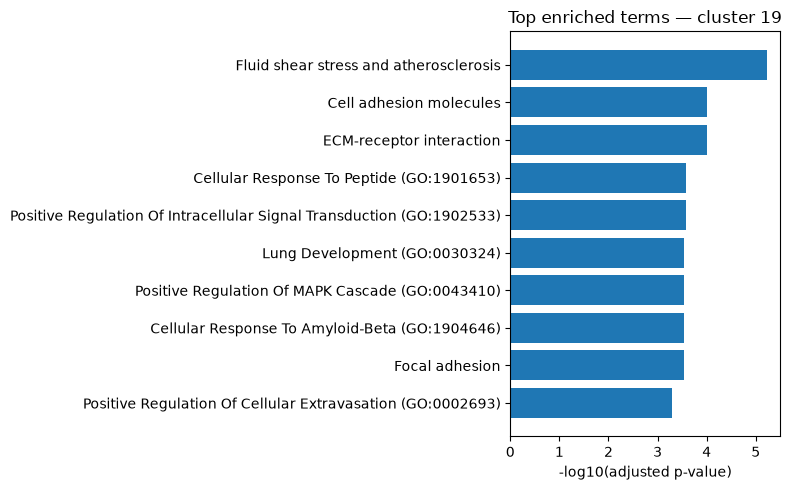

In [52]:
# Barplot of the top enriched terms for a single cluster (edit cluster id as needed)
cluster_to_plot = clusters[19]
top_terms = (
    layer3_enrichment[layer3_enrichment["cluster"] == cluster_to_plot]
    .sort_values("Adjusted P-value")
    .head(10)
)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_terms["Term"], -np.log10(top_terms["Adjusted P-value"]))
ax.invert_yaxis()
ax.set_xlabel("-log10(adjusted p-value)")
ax.set_title(f"Top enriched terms — cluster {cluster_to_plot}")
plt.tight_layout()

In [27]:
top_enriched_terms_per_cluster = (
    layer3_enrichment.sort_values("Adjusted P-value")
    .groupby("cluster", observed=True)["Term"]
    .apply(lambda s: "; ".join(s.head(3)))
    .reindex(clusters)
)

## Consolidation

Merge all three layers into one summary table, and use it to assign the final `cell_type` label (`layer2_label` if filled in, otherwise falls back to `canonical_label`).

In [36]:
n_cells_per_cluster = adata.obs["leiden"].value_counts().reindex(clusters)

cell_type_annotation_summary = (
    layer1_annotation.set_index("cluster")
    .join(layer2_manual_annotation.set_index("cluster"))
    .assign(
        n_cells=n_cells_per_cluster,
        top_enriched_terms=top_enriched_terms_per_cluster,
    )
    .reset_index()
)
# Manual final call, informed by the layer 1-3 evidence above (see preannotation_groups)
cell_type_annotation_summary["final_label"] = cell_type_annotation_summary["cluster"].map(cluster_to_preannotation)
cell_type_annotation_summary.to_csv(f"{annot_dir}/cell_type_annotation_summary.csv", index=False)
cell_type_annotation_summary

,cluster,canonical_label,canonical_score,top_degs,literature_notes,layer2_label,n_cells,top_enriched_terms,final_label
0,0,Immune: T cell,0.443417,"CXCR4, CD3E, EEF1G, CD2, CTLA4, CD44, ITGAL, I...",,,31717,T cell receptor signaling pathway; T Cell Acti...,Treg
1,1,Immune: T cell,0.376795,"CD8A, CD3E, CXCR4, GZMA, CST7, ITGAL, KLRK1, G...",,,10247,T Cell Activation (GO:0042110); Immunoregulato...,T_cytotoxic
2,2,Immune: B cell,0.463669,"CXCR4, MS4A1, EEF1G, TNFRSF13C, CD19, CD79A, B...",,,9740,B cell receptor signaling pathway; Antigen Rec...,B_cell
3,3,Immune: Plasma cell,1.011208,"XBP1, MZB1, TENT5C, SLAMF7, PIM2, DERL3, POU2A...",,,9999,Protein processing in endoplasmic reticulum; R...,Plasma
4,4,Epithelial: Tumor/Malignant,0.556935,"CLPTM1L, EPCAM, PDIA4, LAPTM4B, CDH1, NKX2-1, ...",,,27406,Signaling By Interleukins R-HSA-449147; Cellul...,Tumor_epithelial
5,5,Stromal: Fibroblast,0.249662,"LTBP2, COL5A1, NBL1, CDH11, AEBP1, CCDC80, MMP...",,,19480,Extracellular Matrix Organization R-HSA-147424...,Fibroblast
6,6,Immune: Myeloid,0.309424,"CD68, CD14, SLCO2B1, FCGR2A, MRC1, GRN, MSR1, ...",,,23651,Immune System R-HSA-168256; Phagosome; Neutrop...,Macrophage
7,7,Immune: Myeloid,0.024847,"SOX2-OT, MXD1, LILRA5, CSF3R, CD300E, FPR1, C5...",,,14954,Innate Immune System R-HSA-168249; Immune Syst...,Neutrophil
8,8,Epithelial: Tumor/Malignant,0.551009,"CLPTM1L, EPCAM, PDIA4, CTSH, LAPTM4B, TUBB, P4...",,,1942,"Cell Cycle R-HSA-1640170; Cell Cycle, Mitotic ...",Tumor_epithelial
9,9,Immune: Myeloid,0.042712,"KIT, GATA2, HDC, MS4A2, IL1RL1, SLC18A2, CD44,...",,,3902,Immune System R-HSA-168256; Arachidonic Acid M...,Mast


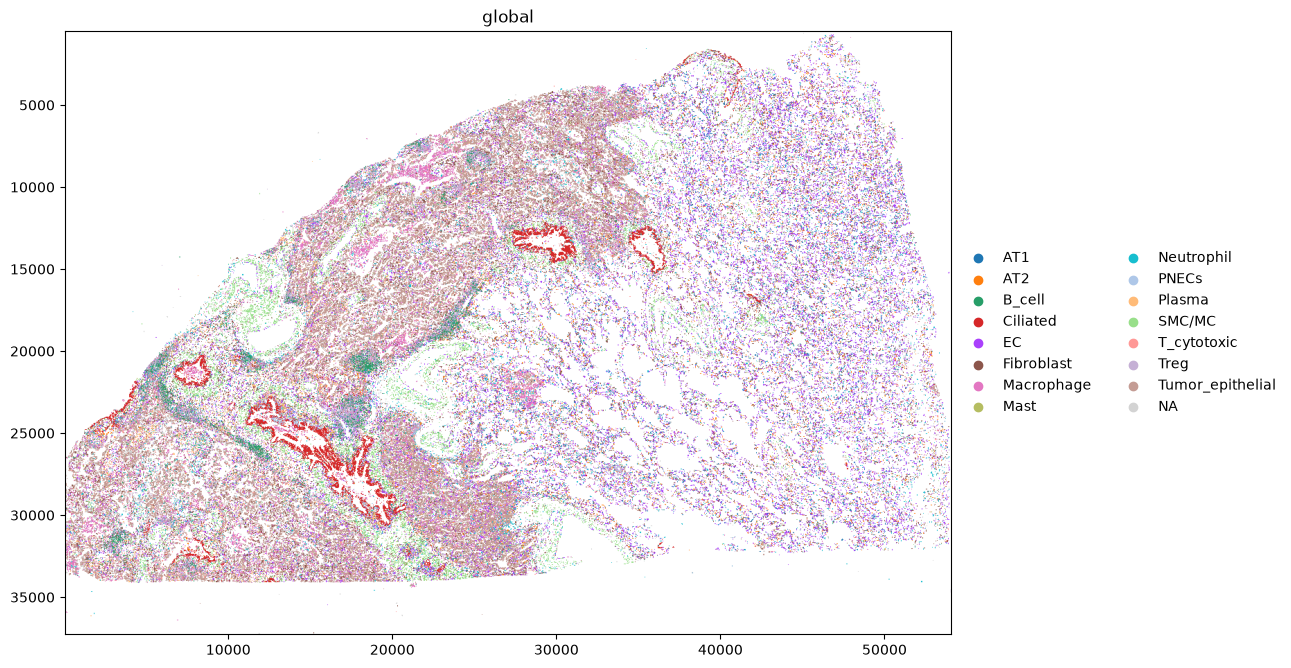

In [37]:
# Map final labels onto the cells and plot spatially
label_map = cell_type_annotation_summary.set_index("cluster")["final_label"]
adata.obs["cell_type"] = adata.obs["leiden"].map(label_map).astype("category")

import re

# score_* columns contain characters (":", "(", "/") invalid for spatialdata's obs validation
adata.obs.rename(columns={c: re.sub(r"[^A-Za-z0-9_.-]", "_", c) for c in adata.obs.columns if c.startswith("score_")}, inplace=True)

sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")
sdata.pl.render_shapes("cell_boundaries", color="cell_type").pl.show(figsize=(12.8, 9.6))

Once `layer2_manual_annotation.csv` has been reviewed/filled in and the `cell_type` labels above look correct, re-save the processed Zarr store to persist them (uncomment below — this overwrites `data/xenium_prime_5k_processed.zarr`).

In [53]:
sdata.write("../../data/spatialdata/xenium_prime_5k_processed_annotated.zarr", overwrite=True)